## **Import Library**

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## **Read Dataset**

In [4]:
df = pd.read_csv("job_salary_prediction_dataset.csv")

## **Data Preprocessing**

For this project im try to predict the salary based on position,country and others features.

### **Basic Overview**

In [5]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


### **Check dataset info**

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


### **Check unique value for every categorical columns**

In [7]:
cat_cols = [
    "job_title",
    "education_level",
    "industry",
    "company_size",
    "location",
    "remote_work"
]

for col in cat_cols:
    print("\n====================")
    print("Column:", col)
    print("Unique values:", df[col].nunique()) # num of uniq value

    print("\nValue counts:")
    print(df[col].value_counts()) # wat are them and how many


Column: job_title
Unique values: 12

Value counts:
job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

Column: education_level
Unique values: 5

Value counts:
education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

Column: industry
Unique values: 10

Value counts:
industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           2484

### **Check numeric columns**

In [8]:
num_cols = ["experience_years", "skills_count", "certifications", "salary"]

df[num_cols].describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


Until here we know that there is no missing value or unnormal value.

### **Check Outliers**

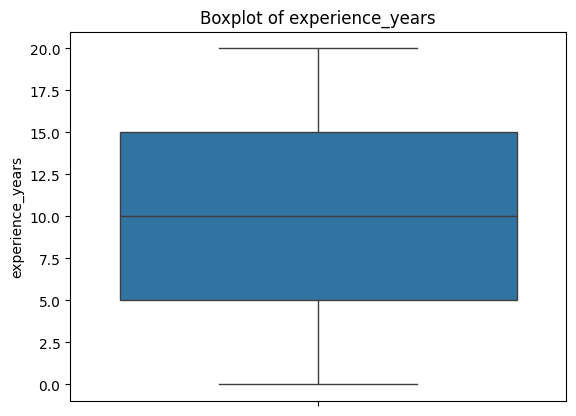

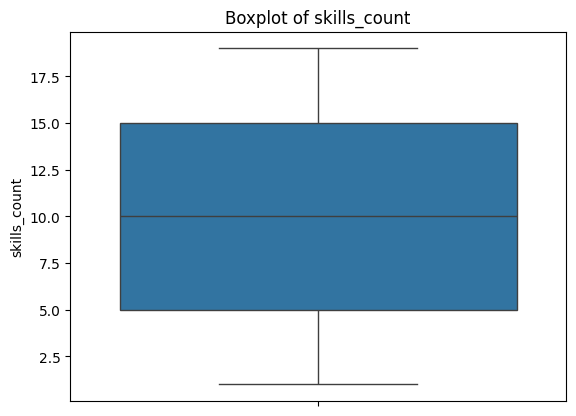

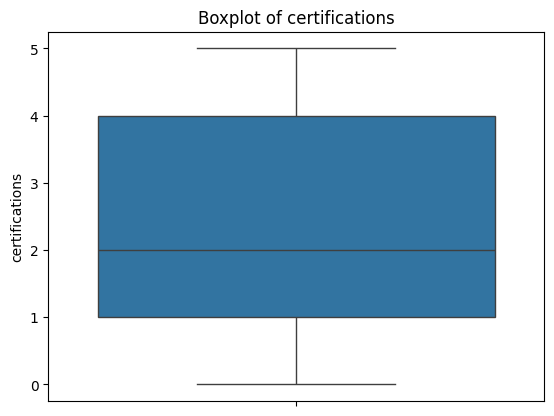

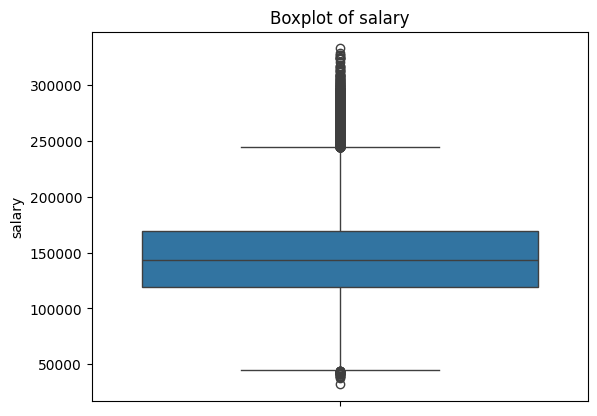

In [9]:
for col in num_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

#### **Checking amount of outliers in salary**

In [10]:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["salary"] < lower_bound) | (df["salary"] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(df) * 100)

Lower bound: 44157.0
Upper bound: 244693.0
Number of outliers: 2336
Percentage of outliers: 0.9344


Outlier analysis using the IQR method identified approximately 0.93% of salary values as outliers. Given their low proportion and likely representation of high-income roles, these values were retained to preserve real-world distribution characteristics.

### **Normalize numeric columns**

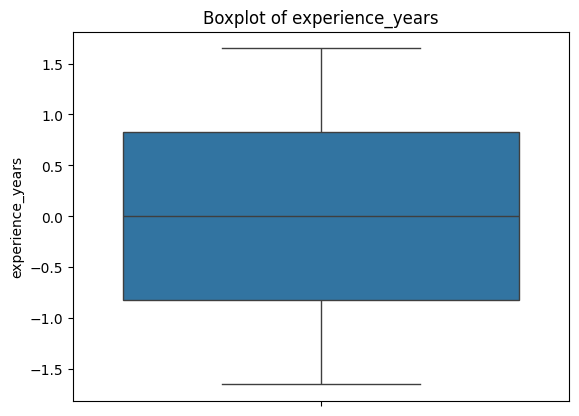

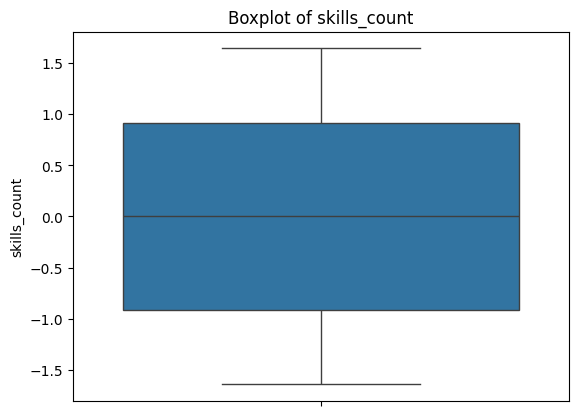

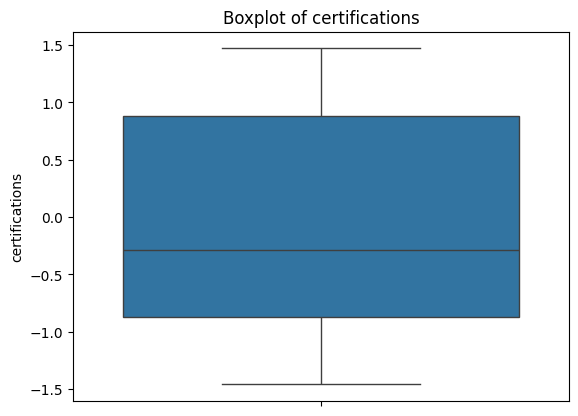

In [11]:
num_cols = ["experience_years", "skills_count", "certifications"]

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

for col in num_cols:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### **Check salary distribution**

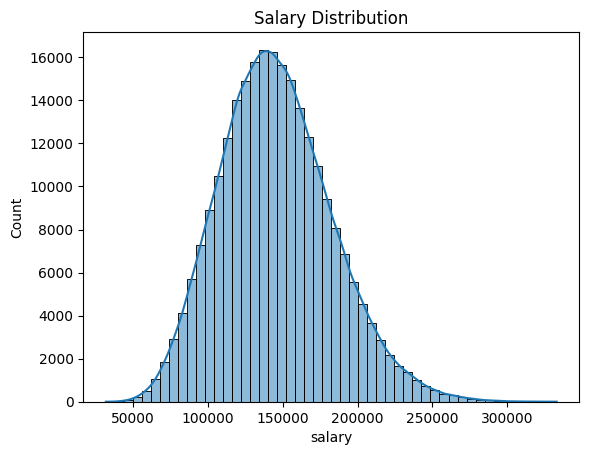

In [12]:
plt.figure()
sns.histplot(df["salary"], bins=50, kde=True)
plt.title("Salary Distribution")
plt.show()

The salary distribution appears approximately normally distributed, indicating that most observations are concentrated around the mean with fewer extreme values on both ends. This suggests a balanced target variable, which is beneficial for regression modelling.

### **Check correlation**

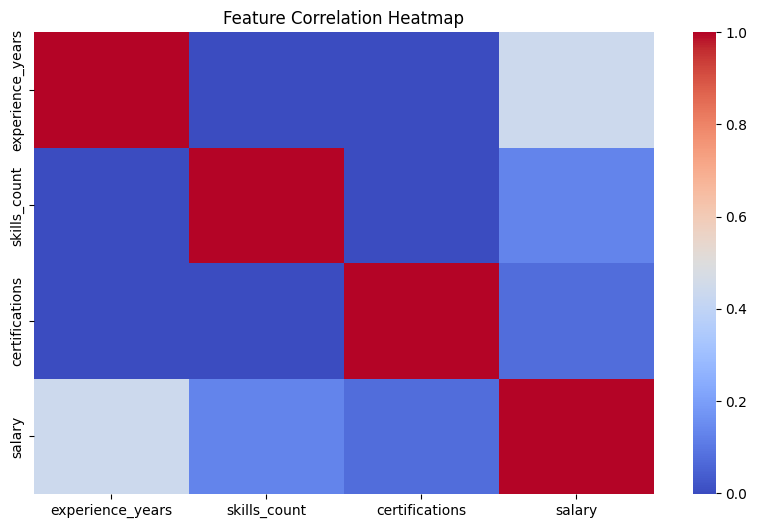

salary              1.000000
experience_years    0.437627
skills_count        0.127300
certifications      0.073819
Name: salary, dtype: float64


In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

print(corr["salary"].sort_values(ascending=False))

Correlation analysis indicates that experience years has the strongest positive relationship with salary (0.44), suggesting it is the most influential feature among the numeric variables. Skills count and certifications show weak correlations, indicating limited linear relationship with salary.

### **One hot for categoric columns**

In [14]:
df = pd.get_dummies(df, columns=cat_cols)

print("New shape after one-hot encoding:")
print(df.shape)

New shape after one-hot encoding:
(250000, 49)


## **Neural Netowrk Training**

### **Train / Test Split**

In [15]:
X = df.drop("salary", axis=1) # drop target
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### **Build MLP Model**

In [24]:
model1 = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model2 = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model3 = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

### **Compile Model**

In [25]:
model1.compile(optimizer='adam', loss='mse', metrics=['mae'])
model2.compile(optimizer='adam', loss='mse', metrics=['mae'])
model3.compile(optimizer='adam', loss='mse', metrics=['mae'])

### **Train Model**

In [27]:
history1 = model1.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7257359872.0000 - mae: 78094.7656 - val_loss: 6775733248.0000 - val_mae: 75005.6562
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6404113920.0000 - mae: 72557.9766 - val_loss: 5948250112.0000 - val_mae: 69435.9688
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5596337152.0000 - mae: 66950.1406 - val_loss: 5169806336.0000 - val_mae: 63831.8906
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4840516608.0000 - mae: 61334.8477 - val_loss: 4446464512.0000 - val_mae: 58244.4414
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 4143129600.0000 - mae: 55788.8633 - val_loss: 3784705536.0000 - val_mae: 52777.9219
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3510056704.0000 - mae: 50390.4648 - val_loss: 3189877504.0000 - val_mae: 47531.2070
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2946146560.0000 - mae: 45241.1445 - val_loss: 2665702144.0000 - val_mae: 425

In [28]:
history2 = model2.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 51467392.0000 - mae: 5477.8149 - val_loss: 51367556.0000 - val_mae: 5474.5942
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 51463232.0000 - mae: 5476.9775 - val_loss: 51402888.0000 - val_mae: 5480.3662
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 51488696.0000 - mae: 5478.5103 - val_loss: 51395532.0000 - val_mae: 5472.6118
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 51480112.0000 - mae: 5479.2700 - val_loss: 51363844.0000 - val_mae: 5469.9883
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 51479660.0000 - mae: 5478.3145 - val_loss: 51384036.0000 - val_mae: 5471.9019
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 51475220.0000 - mae: 5478.0127 - val_loss: 51486116.0000 - val_mae: 5470.5610
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 51477712.0000 - mae: 5477.4019 - val_loss: 51385684.0000 - val_mae: 5472.1050
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━

In [29]:
history3 = model3.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=256
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 64900236.0000 - mae: 5989.3750 - val_loss: 51209932.0000 - val_mae: 5465.9307
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 51026308.0000 - mae: 5464.0327 - val_loss: 50717356.0000 - val_mae: 5456.9585
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 50126280.0000 - mae: 5430.9502 - val_loss: 49155068.0000 - val_mae: 5391.8003
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47526788.0000 - mae: 5312.9922 - val_loss: 45598488.0000 - val_mae: 5220.8115
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 42918704.0000 - mae: 5083.9766 - val_loss: 40217216.0000 - val_mae: 4939.5464
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 37103024.0000 - mae: 4764.5083 - val_loss: 34392888.0000 - val_mae: 4608.5078
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 32522384.0000 - mae: 4497.2827 - val_loss: 31167358.0000 - val_mae: 4413.6782
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━

### **Evaluate Model**

In [32]:
loss1, mae1 = model1.evaluate(X_test, y_test)
print("Model 1 MAE:", mae1)
loss12, mae2 = model2.evaluate(X_test, y_test)
print("Model 2 MAE:", mae2)
loss3, mae3 = model3.evaluate(X_test, y_test)
print("Model 3 MAE:", mae3)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step - loss: 604859776.0000 - mae: 19292.2695
Model 1 MAE: 19292.26953125
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step - loss: 41171276.0000 - mae: 4947.8916
Model 2 MAE: 4947.8916015625
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - loss: 27208290.0000 - mae: 4158.2373
Model 3 MAE: 4158.2373046875


### **Final Comparison Table**

In [33]:
results = pd.DataFrame({
    "Model": ["1-layer", "2-layer", "3-layer"],
    "MAE": [mae1, mae2, mae3]
})

print(results)

     Model           MAE
0  1-layer  19292.269531
1  2-layer   4947.891602
2  3-layer   4158.237305


### **Plot Training**

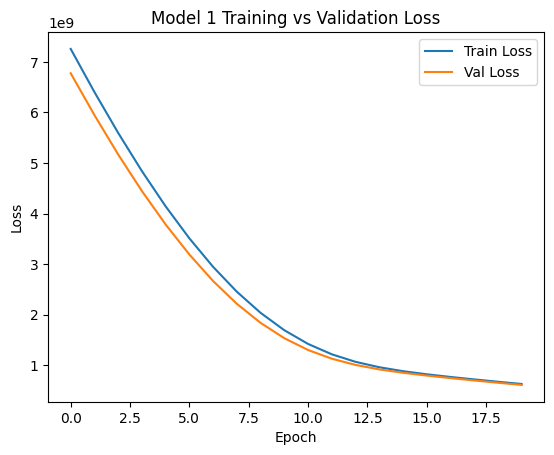

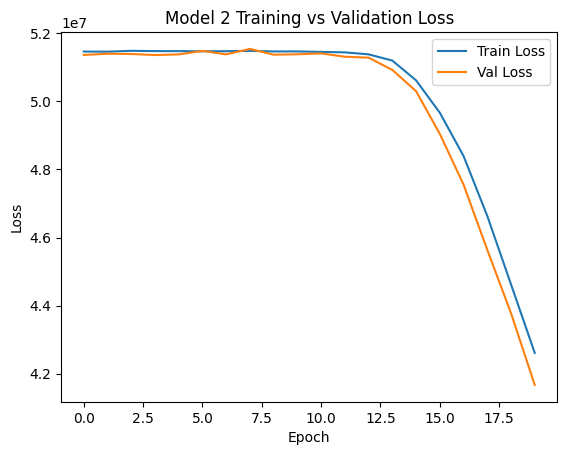

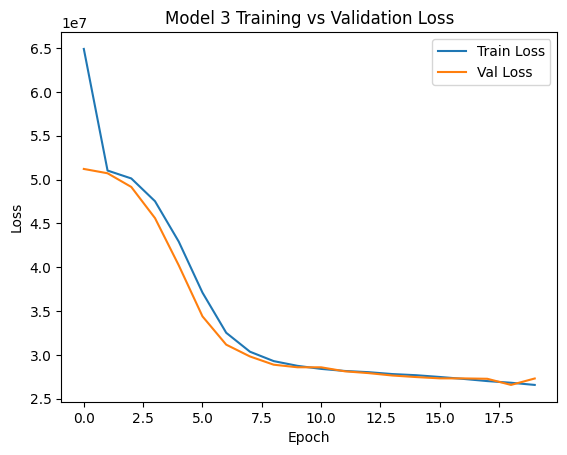

In [44]:
history = [history1,history2,history3]

for i, h in enumerate(history):
    plt.figure()

    plt.plot(h.history['loss'], label='Train Loss')
    plt.plot(h.history['val_loss'], label='Val Loss')

    plt.legend()
    plt.title(f"Model {i+1} Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.show()

| Model   | Architecture   | MAE   | Observation                          |
| ------- | -------------- | ----- | ------------------------------------ |
| Model 1 | 1 Dense layer  | 19292 | Underfitting, Smooth fast drop       |
| Model 2 | 2 Dense layers | 4948  | Slow then sharp improvement, Best learning transition   |
| Model 3 | 3 Dense layers | 4158  | Noisy + crossing curves, High capacity, best final performance|


After these observations, I will choose Model 3 for further optimisation. I noticed that increasing the number of layers generally improves performance; however, as seen from the comparison between the 2-layer and 3-layer models, the MAE only decreases by ~800. Adding more layers may lead to overfitting, and it also increases computational cost, making the improvement less worthwhile.

### **Tunning**

In [60]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)

model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['mae']
)

### **Early Stopping**

In [61]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, # after 5 epoch no improve then stop
    min_delta=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5642506240.0000 - mae: 48617.2461 - val_loss: 114696768.0000 - val_mae: 7927.4966
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 61965008.0000 - mae: 5880.9355 - val_loss: 51108012.0000 - val_mae: 5462.1655
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 50930316.0000 - mae: 5460.1118 - val_loss: 50544560.0000 - val_mae: 5449.4619
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49828920.0000 - mae: 5417.1250 - val_loss: 48731964.0000 - val_mae: 5372.2822
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 46746552.0000 - mae: 5274.9824 - val_loss: 44491460.0000 - val_mae: 5163.6309
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 41474840.0000 - mae: 5007.8989 - val_loss: 38436980.0000 - val_mae: 4838.9624
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 35601552.0000 - mae: 4678.2256 - val_loss: 33284876.0000 - val_mae: 4542.4751
Epoch 8/50
625/625 ━━━━━━━━━━━

### **Final Evalution**

In [63]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 586us/step
MAE: 4028.645751953125
RMSE: 5046.170230977152
R2 Score: 0.9816789031028748


The model achieves a high R² score of 0.982, indicating strong explanatory power. The relatively low MAE and RMSE suggest accurate and stable predictions, with no significant presence of large outliers in prediction errors.

### **Actual vs Predicted Plot**

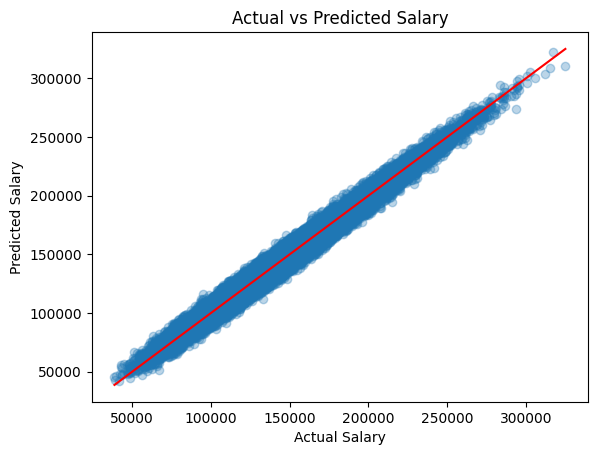

In [ ]:
plt.figure()

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')

plt.show()

The predicted vs actual plot shows a strong alignment along the diagonal line, indicating that the model is able to capture the underlying relationship between features and salary effectively. The tight clustering suggests low variance in prediction errors.

### **Error Distribution**

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 553us/step


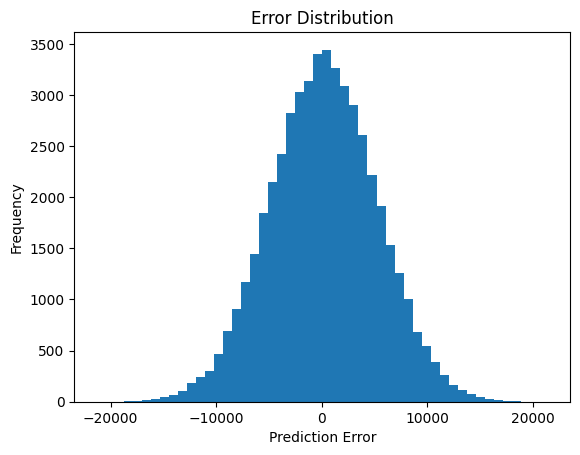

In [66]:
y_pred = model.predict(X_test).flatten()
y_test = y_test.values.flatten()
errors = y_test - y_pred

plt.figure()

plt.hist(errors, bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")

plt.show()

The error distribution follows an approximately normal shape centered around zero, indicating that the model does not exhibit significant bias toward overestimation or underestimation. This suggests that prediction errors are randomly distributed and the model generalises well.